# Linear Regression – Complete End-to-End Project


## PART A – THEORY 

### 1. Define Linear Regression

###### Linear Regression is a supervised learning algorithm used to predict continuous values by finding the relationship between independent and dependent variables.

### 2. General Mathematical Equation of Linear Regression

###### Simple Linear Regression:

###### y=b0+b1x+e

###### Multiple Linear Regression:

###### y=b0+b1x1+b2x2+⋯+bnxn+e

### 3. Objective of OLS Method

###### The objective of OLS (Ordinary Least Squares) is to find the best-fit line by minimizing the sum of squared residuals (errors).

### 4. Define Residual

###### Residual=yi−yi
###### A residual is the difference between the actual value and the predicted value.

### 5. What is R² Score?

##### R2=1−SStot/SSres
##### R² score measures how well the regression model explains the variance in the dependent variable.

## Section 2 – Assumptions


### 1. Linearity

##### The relationship between independent variables and the dependent variable should be linear.
##### If violated, the model may give inaccurate predictions.

### 2. Independence of Errors

##### Residuals (errors) should be independent and not correlated with each other.
##### If violated, predictions become unreliable and biased.

### 3. Homoscedasticity

##### The variance of residuals should remain constant across all levels of predictions.
##### If violated (heteroscedasticity), the model’s estimates become inefficient.

### 4. Normality of Residuals

##### Residuals should follow a normal distribution.
##### If violated, hypothesis testing and confidence intervals may become inaccurate.

### 5. No Multicollinearity

##### Independent variables should not be highly correlated with each other.
##### If violated, coefficient estimates become unstable and difficult to interpret.

### 6.What Happens if Assumptions are Violated?

##### If regression assumptions are violated, the model may produce biased results, poor predictions, inaccurate coefficients, and unreliable statistical conclusions.

## Section 3 – Regularization & Bias-Variance 


### 1. Define Bias and Variance
#### Bias

##### Bias is the error caused by overly simple assumptions in the model. High bias leads to underfitting.

#### Variance

##### Variance is the error caused by the model being too sensitive to training data. High variance leads to overfitting.

### 2. Underfitting and Overfitting
#### Underfitting

##### Underfitting occurs when the model is too simple and fails to learn patterns from the data.

#### Overfitting

##### Overfitting occurs when the model memorizes training data and performs poorly on unseen data.

### 3. Ridge Regression Objective Function

##### min(∑(yi−yi)2+λ∑wj2)

##### Ridge adds L2 penalty to reduce large coefficients.

### 4. Lasso Regression Objective Function

##### min(∑(yi-yi)2+λ∑∣wj∣)

##### Lasso adds L1 penalty and can shrink some coefficients to zero.

### 5. ElasticNet Objective Function
##### min(∑(yi-yi)2+λ1∑∣wj∣+λ2∑wj2)
##### ElasticNet combines both Ridge and Lasso penalties.

### 6. Difference Between Ridge and Lasso
#### Ridge	Lasso
##### Uses L2 regularization	Uses L1 regularization
##### Reduces coefficient values	Can make coefficients exactly zero
##### Keeps all features	Performs feature selection
### 7. Why Feature Scaling is Important for Regularization?

##### Regularization depends on coefficient values.
##### If features are not scaled, variables with larger values dominate the penalty term, leading to unfair regularization.

#  PART B – PRACTICAL IMPLEMENTATION 


### Step 1 – Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,mean_squared_error,r2_score)

### Step 2 – Load Dataset


In [2]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [3]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [5]:
df.shape

(442, 10)

In [6]:
df.dtypes

age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object

In [7]:
df.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [11]:
# Add target column
df['target'] = diabetes.target

# Step 3 – Exploratory Data Analysis


## summary statistics.

In [8]:
print(df.describe(include='all'))

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17  
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761

### INSIGHTS
##### The dataset contains medical features like BMI, blood pressure, and glucose levels that may influence diabetes progression.
##### Summary statistics help identify data distribution, feature ranges, and possible outliers before model building.

## Plot correlation heatmap.


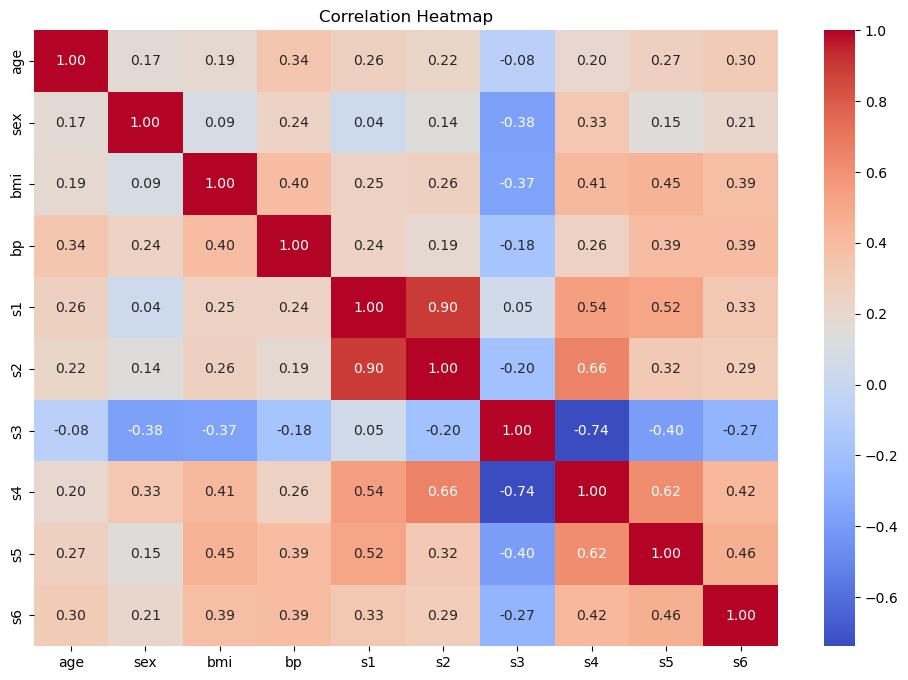

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

### INSIGHTS
##### Features with higher positive or negative correlation with the target variable may have stronger influence on diabetes progression.
##### Heatmaps help identify relationships between variables and detect multicollinearity.

## highly correlated features.


In [12]:
corr_with_target = df.corr()['target'].sort_values(ascending=False)

print(corr_with_target)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [13]:
# Highly correlated features
high_corr = corr_with_target[abs(corr_with_target) > 0.5]

print(high_corr)

target    1.000000
bmi       0.586450
s5        0.565883
Name: target, dtype: float64


### Insight:
##### Features with high positive correlation increase along with the target variable.
##### Features with high negative correlation decrease as the target variable increases.

## Observations.


##### BMI (bmi) shows one of the highest positive correlations with the target variable, indicating it strongly influences diabetes progression.
##### Features like s5 and bp also have moderate positive correlation with the target.
##### No feature shows extremely high correlation with another feature, so severe multicollinearity is less likely.
##### Correlation heatmaps help identify important predictors and relationships before model building.

# Step 4 – Train-Test Split


In [14]:
# Features and target
X = df.drop('target', axis=1)
y = df['target']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


# Step 5 – Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why scaling is necessary:
##### Features may have different ranges and units.
##### Scaling standardizes the data so that all features contribute equally.
##### Algorithms like KNN, SVM, and Gradient Descent perform better with scaled data.

# Step 6 – OLS Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_train_pred = model.predict(X_train_scaled)

In [26]:
y_test_pred = model.predict(X_test_scaled)


In [24]:
train_r2 = r2_score(y_train, y_train_pred)
train_r2

0.5279193863361498

In [31]:
test_r2 = r2_score(y_test, y_test_pred)
test_r2

0.4526027629719196

In [27]:
mse = mean_squared_error(y_test,y_test_pred)
mse

2900.193628493481

In [29]:
rmse = np.sqrt(mse)
rmse

np.float64(53.85344583676592)

In [32]:
print("Train R2 Score:", train_r2)
print("Test R2 Score:", test_r2)


Train R2 Score: 0.5279193863361498
Test R2 Score: 0.4526027629719196


# Step 7 – Ridge Regression


In [34]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import pandas as pd

# Different alpha values
alpha_values = [0.01, 0.1, 1, 10, 100]

# Store results
results = []

for alpha in alpha_values:

    # Create Ridge model
    ridge = Ridge(alpha=alpha)

    # Train model
    ridge.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)

    # R2 scores
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    results.append([alpha, train_r2, test_r2])

# Create results DataFrame
results_df = pd.DataFrame(
    results,
    columns=['Alpha', 'Train_R2', 'Test_R2']
)

# Display results
print(results_df)

# Best alpha based on highest Test R2
best_alpha = results_df.loc[
    results_df['Test_R2'].idxmax(),
    'Alpha'
]

print("\nBest Alpha:", best_alpha)

# Coefficient shrinkage
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_best.coef_
})

print("\nCoefficients:\n")
print(coefficients)

    Alpha  Train_R2   Test_R2
0    0.01  0.527919  0.452625
1    0.10  0.527915  0.452818
2    1.00  0.527632  0.454147
3   10.00  0.524798  0.457211
4  100.00  0.511804  0.460524

Best Alpha: 100.0

Coefficients:

  Feature  Coefficient
0     age     2.093789
1     sex    -8.168076
2     bmi    21.561936
3      bp    13.926917
4      s1    -2.898262
5      s2    -4.087197
6      s3    -9.059339
7      s4     6.683867
8      s5    16.477222
9      s6     4.688816


### Observations:
##### R² scores help compare model performance for different alpha values.
##### The alpha with the highest Test R² is considered the best alpha.
##### As alpha increases, Ridge Regression shrinks coefficients toward zero, reducing model complexity and overfitting.

# Step 8 – Lasso Regression


In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import pandas as pd

# Create Lasso model
lasso = Lasso(alpha=0.1)

# Train model
lasso.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

# R2 scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Lasso Train R2 Score:", train_r2)
print("Lasso Test R2 Score:", test_r2)

# Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

print("\nLasso Coefficients:\n")
print(coefficients)

# Features with zero coefficients
zero_features = coefficients[coefficients['Coefficient'] == 0]

print("\nFeatures with Zero Coefficients:\n")
print(zero_features)

Lasso Train R2 Score: 0.5272214154674504
Lasso Test R2 Score: 0.455541399027904

Lasso Coefficients:

  Feature  Coefficient
0     age     1.730451
1     sex   -11.316359
2     bmi    25.824627
3      bp    16.644252
4      s1   -29.358412
5      s2    13.275844
6      s3     0.547948
7      s4    10.236168
8      s5    29.632826
9      s6     2.393475

Features with Zero Coefficients:

Empty DataFrame
Columns: [Feature, Coefficient]
Index: []


### Observations:
##### Lasso Regression can shrink some coefficients exactly to zero, performing feature selection.
##### Ridge Regression shrinks coefficients but usually keeps all features.
##### Compare Test R² scores to determine which model performs better on unseen data.

# Step 9 – ElasticNet


In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
import pandas as pd

# Different alpha and l1_ratio values
alpha_values = [0.01, 0.1, 1, 10]
l1_ratios = [0.2, 0.5, 0.8]

# Store results
results = []

for alpha in alpha_values:
    for l1_ratio in l1_ratios:

        # Create ElasticNet model
        elastic = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            random_state=42
        )

        # Train model
        elastic.fit(X_train_scaled, y_train)

        # Predictions
        y_train_pred = elastic.predict(X_train_scaled)
        y_test_pred = elastic.predict(X_test_scaled)

        # R2 scores
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        # Store results
        results.append([
            alpha,
            l1_ratio,
            train_r2,
            test_r2
        ])

# Results DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        'Alpha',
        'L1_Ratio',
        'Train_R2',
        'Test_R2'
    ]
)

print(results_df)

# Best model
best_model = results_df.loc[
    results_df['Test_R2'].idxmax()
]

print("\nBest Parameters:\n")
print(best_model)

    Alpha  L1_Ratio  Train_R2   Test_R2
0    0.01       0.2  0.526775  0.455417
1    0.01       0.5  0.527230  0.454897
2    0.01       0.8  0.527707  0.454011
3    0.10       0.2  0.522454  0.459798
4    0.10       0.5  0.523618  0.458970
5    0.10       0.8  0.524914  0.457339
6    1.00       0.2  0.472806  0.441020
7    1.00       0.5  0.493303  0.454771
8    1.00       0.8  0.513079  0.465524
9   10.00       0.2  0.207781  0.206849
10  10.00       0.5  0.250338  0.248817
11  10.00       0.8  0.336461  0.333562

Best Parameters:

Alpha       1.000000
L1_Ratio    0.800000
Train_R2    0.513079
Test_R2     0.465524
Name: 8, dtype: float64


### Observations:
##### ElasticNet combines both Ridge (L2) and Lasso (L1) regularization.
##### alpha controls regularization strength, while l1_ratio controls the balance between Lasso and Ridge penalties.
##### ElasticNet is useful when features are highly correlated and when feature selection is needed.

# Step 10 – Model Comparison


In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# ---------------- Linear Regression ----------------
linear_train_pred = model.predict(X_train_scaled)
linear_test_pred = model.predict(X_test_scaled)

linear_train_r2 = r2_score(y_train, linear_train_pred)
linear_test_r2 = r2_score(y_test, linear_test_pred)
linear_mse = mean_squared_error(y_test, linear_test_pred)

# ---------------- Ridge Regression ----------------
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)
ridge_mse = mean_squared_error(y_test, ridge_test_pred)

# ---------------- Lasso Regression ----------------
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)
lasso_mse = mean_squared_error(y_test, lasso_test_pred)

# ---------------- ElasticNet ----------------
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train_scaled, y_train)

elastic_train_pred = elastic.predict(X_train_scaled)
elastic_test_pred = elastic.predict(X_test_scaled)

elastic_train_r2 = r2_score(y_train, elastic_train_pred)
elastic_test_r2 = r2_score(y_test, elastic_test_pred)
elastic_mse = mean_squared_error(y_test, elastic_test_pred)

# ---------------- Comparison Table ----------------
comparison_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'],
    'Train_R2': [
        linear_train_r2,
        ridge_train_r2,
        lasso_train_r2,
        elastic_train_r2
    ],
    'Test_R2': [
        linear_test_r2,
        ridge_test_r2,
        lasso_test_r2,
        elastic_test_r2
    ],
    'MSE': [
        linear_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse
    ]
})

print(comparison_table)

# Best model based on highest Test R2
best_model = comparison_table.loc[
    comparison_table['Test_R2'].idxmax()
]

print("\nBest Performing Model:\n")
print(best_model)

               Model  Train_R2   Test_R2          MSE
0  Linear Regression  0.527919  0.452603  2900.193628
1              Ridge  0.527632  0.454147  2892.014566
2              Lasso  0.527221  0.455541  2884.624289
3         ElasticNet  0.523618  0.458970  2866.461255

Best Performing Model:

Model        ElasticNet
Train_R2       0.523618
Test_R2         0.45897
MSE         2866.461255
Name: 3, dtype: object


# Step 11 – Assumption Checking

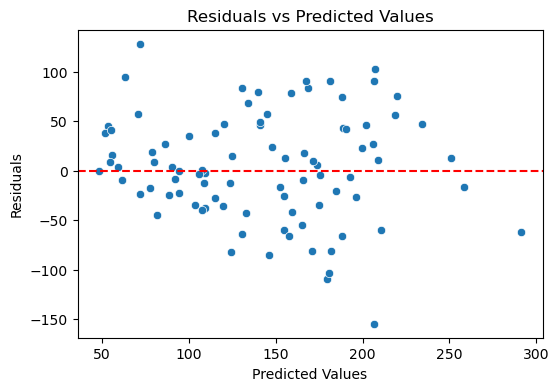

In [38]:
# Predictions and residuals
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred

# -------------------------------
# 1. Check Linearity
# -------------------------------
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()


### Observation:
#####  Random scatter around zero indicates linearity assumption is reasonably satisfied.


###  2. Check Normality of Residuals

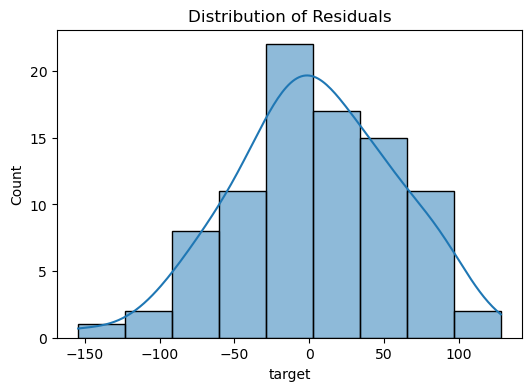

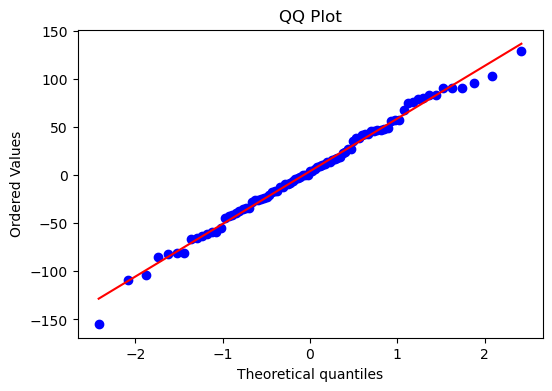

In [40]:
import scipy.stats as stats
plt.figure(figsize=(6, 4))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()

# QQ Plot
plt.figure(figsize=(6, 4))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()


###  Observation:
#####  If residuals approximately follow a bell shape and points align with the diagonal in QQ plot,
#####  normality assumption is satisfied.


### 3. Check Homoscedasticity

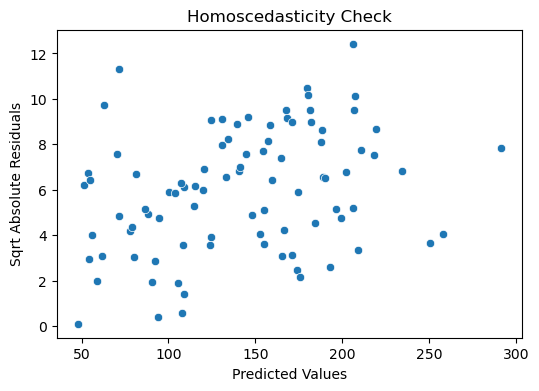

In [41]:

plt.figure(figsize=(6, 4))

sns.scatterplot(x=y_pred, y=np.sqrt(np.abs(residuals)))

plt.xlabel("Predicted Values")
plt.ylabel("Sqrt Absolute Residuals")
plt.title("Homoscedasticity Check")

plt.show()


### Observation:
#####  Uniform spread of residuals indicates constant variance (homoscedasticity).


### 4. Calculate VIF


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = X_scaled_df.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_scaled_df.values, i
    )
    for i in range(X_scaled_df.shape[1])
]

print(vif_data)



  Feature        VIF
0     age   1.217114
1     sex   1.268854
2     bmi   1.573561
3      bp   1.422084
4      s1  55.252137
5      s2  35.759309
6      s3  14.285594
7      s4   9.333044
8      s5  10.071155
9      s6   1.500654


### Observation:
#####  VIF > 5 or 10 indicates multicollinearity problem.
##### Lower VIF values indicate features are not highly correlated

# Step 12 – Cross Validation


In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Create model
model = LinearRegression()

# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

# Train model on full training data
model.fit(X_train_scaled, y_train)

# Test prediction
y_test_pred = model.predict(X_test_scaled)

# Test R2 score
test_r2 = r2_score(y_test, y_test_pred)

# Results
print("Cross Validation Scores:", cv_scores)

print("\nAverage CV Score:", np.mean(cv_scores))

print("Test R2 Score:", test_r2)

Cross Validation Scores: [0.54760189 0.36123934 0.50481226 0.61773622 0.21489265]

Average CV Score: 0.44925647412212166
Test R2 Score: 0.4526027629719196


### Observations:
##### If cross-validation scores are close to the test score, the model is stable and generalizes well.
##### Large differences between CV score and test score may indicate overfitting or unstable model performance.
##### Consistent CV scores across folds indicate reliable model behavior.